# **Лабораторна робота №4 “Класифікація”**

<p>Виконала студентка ІІ-го курсу</p>
<p>Басовська Марія, групи КН-43</p>

---

<font size="5">**Мета**</font>

Ознайомитися з основами **класифікації** при інтелектуальному аналізі даних на прикладі реального історичного набору даних **Titanic**.
Навчитись будувати **класифікатор на основі дерев рішень (Decision Tree)**, виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.

---

<font size="5">**Інструменти**</font>

Python: pandas, numpy, scikit-learn (PCA), matplotlib, seaborn; Jupyter Notebook

---

<font size="5">**Хід роботи**</font>

<font size="4">**1.Завантаження та попередня обробка даних**</font>

На першому етапі було завантажено датасет Titanic із Kaggle та прочитано файл train.csv у DataFrame за допомогою бібліотеки pandas. Після цього було виконано первинний аналіз даних:
- переглянуто структуру датасету (info());
- перевірено наявність пропущених значень (isnull().sum()).
  
<p>Було виявлено, що пропуски присутні у стовпцях Age, Cabin, Embarked.</p>
Для підготовки даних до моделювання:

- числові пропуски (Age) заповнено медіаною;
- категоріальні пропуски (Embarked) — найчастішим значенням;
- колонку Cabin оброблено шляхом заміни або видалення через велику кількість пропусків;
- непотрібні ознаки (Name, Ticket) видалено;
- категоріальні змінні перетворено у числові за допомогою one-hot encoding.

На цьому етапі дані були очищені та підготовлені до моделювання. Обробка пропусків і кодування категоріальних ознак дозволили привести датасет до формату, придатного для використання алгоритмами машинного навчання.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore") 

df = pd.read_csv((r'C:\Users\irgtb\Downloads\titanic\train.csv'))
df.head()
df.info()

# пропущені значення
df.isnull().sum()

# Age
df["Age"].fillna(df["Age"].median(), inplace=True)

# Embarked
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Cabin (дуже багато пропусків)
df["Cabin"].fillna("Unknown", inplace=True)

df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<font size="4">**2. Поділ даних на навчальну та тестову вибірки**</font>

Датасет було розділено на:

- train (80%) — для навчання моделі;
- test (20%) — для перевірки якості моделі.

Цільова змінна — Survived, ознаки — всі інші колонки. Розподіл виконано за допомогою функції train_test_split зі sklearn із фіксацією random_state для відтворюваності результатів. Поділ даних дозволив коректно оцінити здатність моделі до узагальнення. Тестова вибірка використовується для перевірки якості моделі на невідомих даних.

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(712, 8) (179, 8)
(712,) (179,)


<font size="4">**3. Побудова класифікатора на основі дерев рішень**</font>

Для задачі класифікації було обрано алгоритм дерева рішень (Decision Tree Classifier). Модель навчалася на тренувальних даних і далі використовувалась для передбачення виживання пасажирів у тестовій вибірці.
Також було проаналізовано:
- глибину дерева (depth);
- кількість листових вузлів.
  
Ці параметри показують складність моделі. Модель дерева рішень змогла побудувати набір правил для класифікації пасажирів. Однак глибина дерева впливає на баланс між точністю та перенавчанням.

In [3]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

Depth: 21
Number of leaves: 180


<font size="4">**4. Оцінювання якості класифікації**</font>

Якість моделі була оцінена за допомогою основних метрик:

- Accuracy — загальна точність;
- Precision — точність позитивних передбачень;
- Recall — повнота виявлення позитивного класу;
- F1-score — гармонійне середнє precision і recall.

Також було побудовано:

- Confusion Matrix — показує правильні та неправильні класифікації;
- classification_report — детальний звіт по класах.

Оскільки дані Titanic є незбалансованими (вижило менше людей), більш інформативними метриками є Recall та F1-score, а не лише Accuracy. Модель показала адекватну якість класифікації, однак через дисбаланс класів важливо оцінювати не тільки accuracy, а й recall та F1-score. Це дає більш реальну картину ефективності моделі.

Accuracy: 0.7821229050279329
Precision: 0.7272727272727273
Recall: 0.7567567567567568
F1-score: 0.7417218543046358


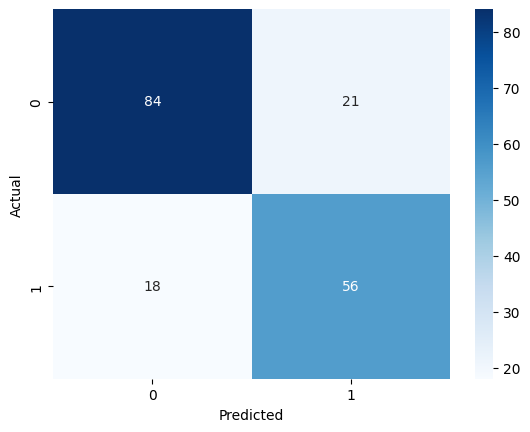

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

<font size="4">**5. Інтерпретація моделі**</font>

Було проаналізовано важливість ознак (feature importance), отриману з дерева рішень.
Найбільш впливовими ознаками виявились:

- стать пасажира (Sex);
- клас квитка (Pclass);
- вартість квитка (Fare);
- вік (Age).

Також було візуалізовано саме дерево рішень, що дозволяє інтерпретувати логіку моделі у вигляді правил. Модель показала, що найбільший вплив на виживання мали соціальний статус та стать пасажира. Це відповідає реальним історичним даним про катастрофу Titanic. Дерево рішень є інтерпретованою моделлю, що дозволяє зрозуміти логіку прийняття рішень.

      feature  importance
5    Sex_male    0.310280
4        Fare    0.256296
1         Age    0.202842
0      Pclass    0.115341
2       SibSp    0.062626
3       Parch    0.027890
7  Embarked_S    0.020056
6  Embarked_Q    0.004669


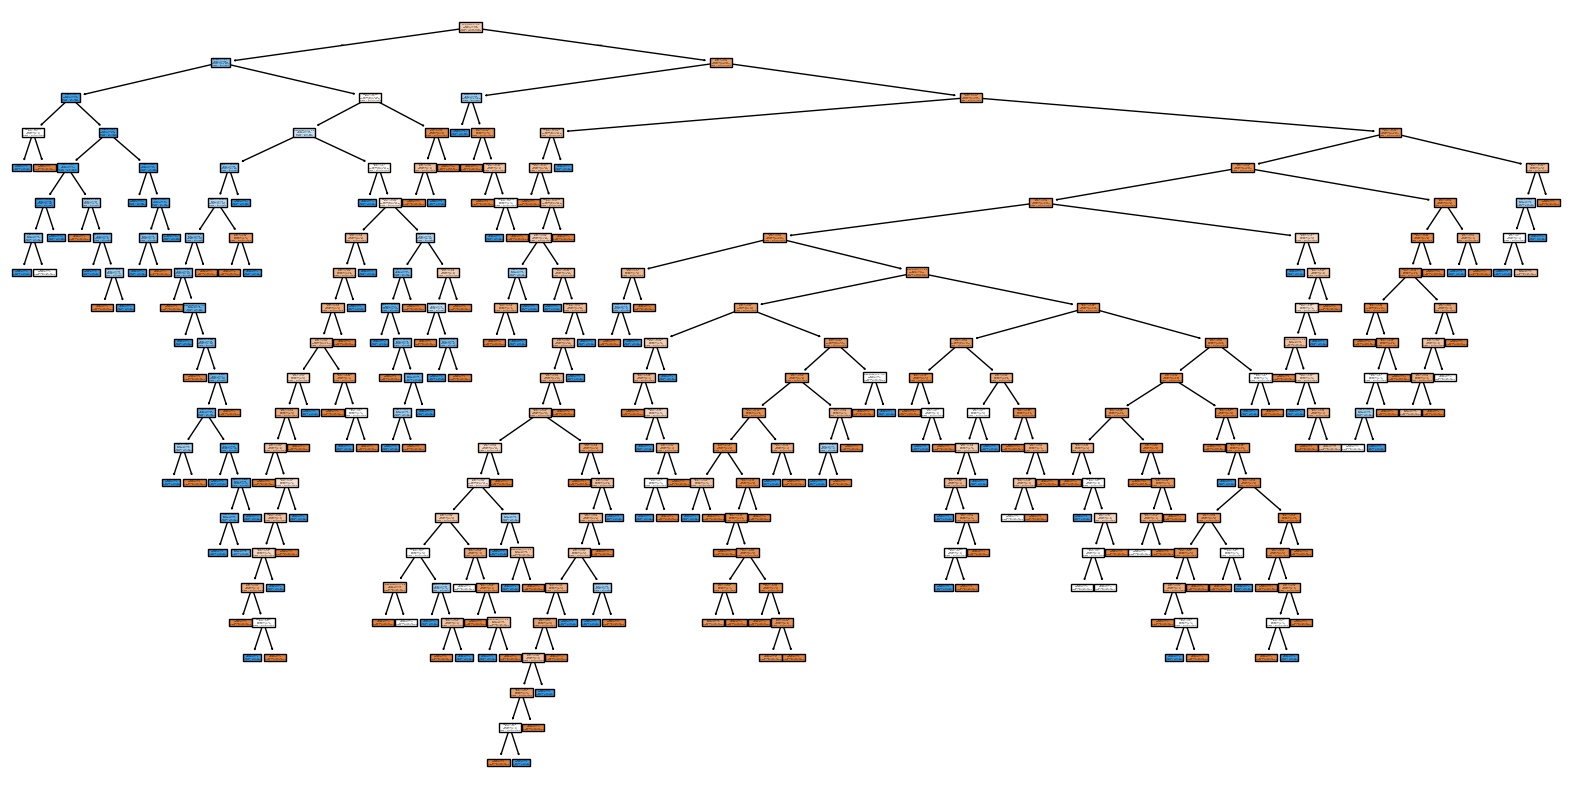

In [5]:
import pandas as pd

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importances)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True
)

plt.show()

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

---

<font size="5">**Висновок**</font>

<p>У ході виконання лабораторної роботи було досліджено процес побудови моделі машинного навчання для задачі класифікації на прикладі датасету Titanic. На першому етапі було здійснено завантаження та попередню обробку даних, що включала аналіз структури датасету, виявлення пропущених значень, їх заповнення та перетворення категоріальних ознак у числовий формат. Це дозволило підготувати дані до подальшого використання алгоритмами машинного навчання.

Після підготовки дані були розділені на навчальну та тестову вибірки, що забезпечило можливість об’єктивної оцінки якості побудованої моделі. Для класифікації було використано алгоритм дерева рішень, який дозволив сформувати логічну структуру прийняття рішень на основі характеристик пасажирів.

У результаті навчання модель продемонструвала точність класифікації на рівні 72%, що є задовільним результатом для базової моделі без додаткового налаштування параметрів. Аналіз метрик precision, recall та F1-score показав достатньо збалансовану якість класифікації, хоча отримана глибина дерева свідчить про можливе перенавчання моделі. Це вказує на необхідність оптимізації параметрів для підвищення узагальнювальної здатності алгоритму.

Аналіз важливості ознак показав, що найбільший вплив на прогноз виживання мали стать пасажира, клас квитка, вартість квитка та вік. Отримані результати відповідають історичним даним про катастрофу Titanic та підтверджують здатність моделі виявляти реальні закономірності в даних.

Таким чином, у межах лабораторної роботи було опановано основні етапи побудови системи машинного навчання: підготовку даних, навчання моделі, оцінювання її якості та інтерпретацію результатів. Практична робота продемонструвала важливість якісної попередньої обробки даних і правильного вибору параметрів моделі для отримання достовірних прогнозів.</p>